In [ ]:
import os
import codecs
import pandas as pd
import numpy as np
import nltk
from nltk.corpus import stopwords
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score


print("📥 Downloading dataset from Kaggle...")
path = kagglehub.dataset_download("hijest/genre-classification-dataset-imdb")
print(f"✅ Dataset downloaded to: {path}")

train_file_path = os.path.join(path, "Genre Classification Dataset", "train_data.txt")


print("📖 Parsing dataset lines...")
train_data = []

with codecs.open(train_file_path, 'r', encoding='utf8') as f:
    for line in f:
        if line.strip():

            parts = line.strip().split(" ::: ")
            if len(parts) == 4:
                train_data.append({
                    "id": parts[0],
                    "title": parts[1],
                    "genre": parts[2],
                    "description": parts[3]
                })

df = pd.DataFrame(train_data)
print(f"📊 Loaded {len(df)} movies.")
print(df[['title', 'genre']].head())


print("🧹 Preprocessing movie descriptions...")
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_description(text):
    text = text.lower()

    words = [word for word in text.split() if word.isalpha() and word not in stop_words]
    return " ".join(words)


df_subset = df.sample(n=20000, random_state=42) if len(df) > 20000 else df
df_subset['clean_desc'] = df_subset['description'].apply(clean_description)


X = df_subset['clean_desc']
y = df_subset['genre']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("🧪 Extracting TF-IDF Features...")
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


print("🚀 Training Logistic Regression classifier...")

model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train_tfidf, y_train)


y_pred = model.predict(X_test_tfidf)

print("\n🎯 --- EVALUATION PERFORMANCE ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))





def predict_movie_genre(custom_plot):
    cleaned = clean_description(custom_plot)
    features = vectorizer.transform([cleaned])
    predicted_genre = model.predict(features)[0]
    return predicted_genre

custom_plot = "A group of rogue astronauts must travel into a massive wormhole to find a habitable planet and save humanity from an environmental collapse."
print("\n🔮 Testing custom plot context prediction:")
print(f"Plot: '{custom_plot}'")
print(f"Predicted Genre ➔ {predict_movie_genre(custom_plot).upper()}")

📥 Downloading dataset from Kaggle...
Using Colab cache for faster access to the 'genre-classification-dataset-imdb' dataset.
✅ Dataset downloaded to: /kaggle/input/genre-classification-dataset-imdb
📖 Parsing dataset lines...
📊 Loaded 54214 movies.
                              title     genre
0      Oscar et la dame rose (2009)     drama
1                      Cupid (1997)  thriller
2  Young, Wild and Wonderful (1980)     adult
3             The Secret Sin (1915)     drama
4            The Unrecovered (2007)     drama
🧹 Preprocessing movie descriptions...


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


🧪 Extracting TF-IDF Features...
🚀 Training Logistic Regression classifier...

🎯 --- EVALUATION PERFORMANCE ---
Accuracy Score: 0.4515

Classification Report:

              precision    recall  f1-score   support

      action       0.26      0.44      0.33        90
       adult       0.17      0.31      0.22        35
   adventure       0.15      0.32      0.21        44
   animation       0.16      0.23      0.19        39
   biography       0.03      0.04      0.03        27
      comedy       0.57      0.42      0.48       553
       crime       0.14      0.28      0.19        43
 documentary       0.74      0.64      0.68       954
       drama       0.66      0.36      0.47      1015
      family       0.07      0.13      0.09        55
     fantasy       0.10      0.12      0.11        26
   game-show       0.57      0.67      0.62        12
     history       0.09      0.16      0.12        19
      horror       0.45      0.64      0.53       160
       music       0.30      0

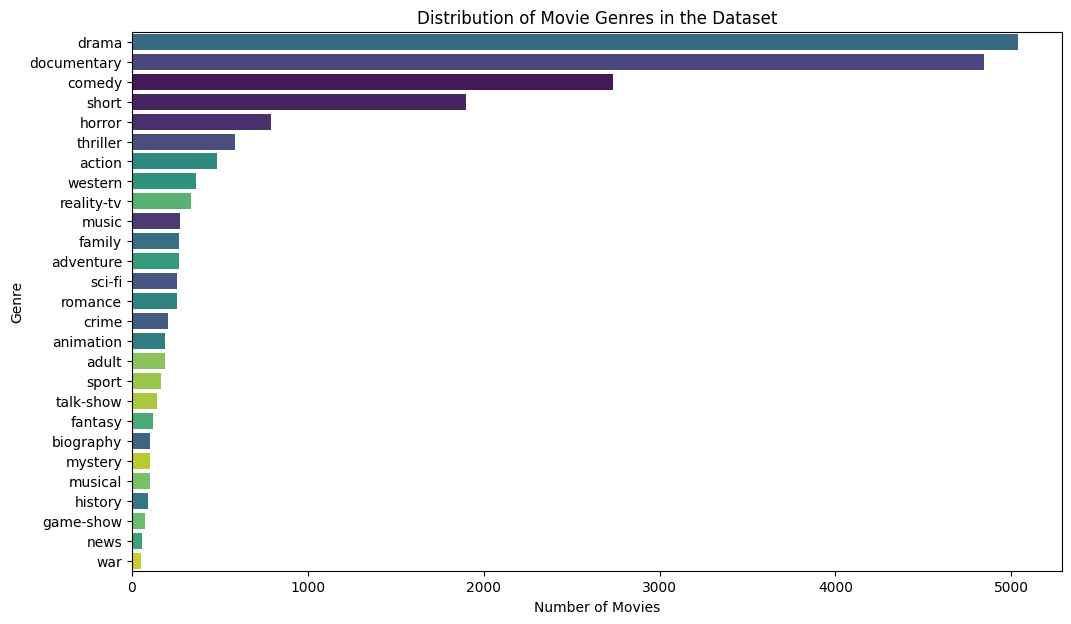

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the distribution of genres using df_subset
plt.figure(figsize=(12, 7))
sns.countplot(y='genre', data=df_subset, order=df_subset['genre'].value_counts().index, palette='viridis', hue='genre', legend=False)
plt.title('Distribution of Movie Genres in the Dataset')
plt.xlabel('Number of Movies')
plt.ylabel('Genre')
plt.show()

--- Class Distribution ---
Class
0    982
1     18
Name: count, dtype: int64
Fraud accounts for 1.800% of the dataset.

⚙️ Applying SMOTE to balance the training set...
Original training shape: (800, 6)
Resampled training shape: (1572, 6)

🚀 Training Random Forest Classifier (this may take a minute)...

🎯 --- MODEL METRICS ---
Confusion Matrix:
[[186  10]
 [  4   0]]

Classification Report:
              precision    recall  f1-score   support

 Genuine (0)       0.98      0.95      0.96       196
   Fraud (1)       0.00      0.00      0.00         4

    accuracy                           0.93       200
   macro avg       0.49      0.47      0.48       200
weighted avg       0.96      0.93      0.94       200

Area Under Precision-Recall Curve (AUPRC): 0.0191


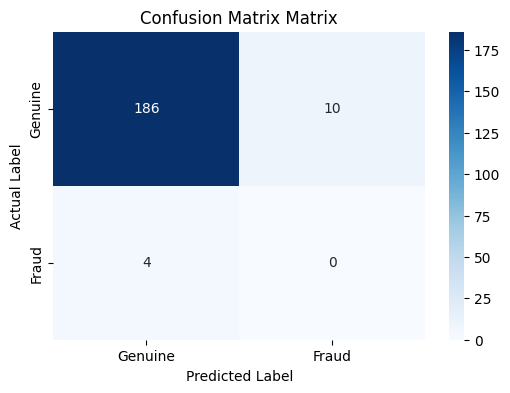

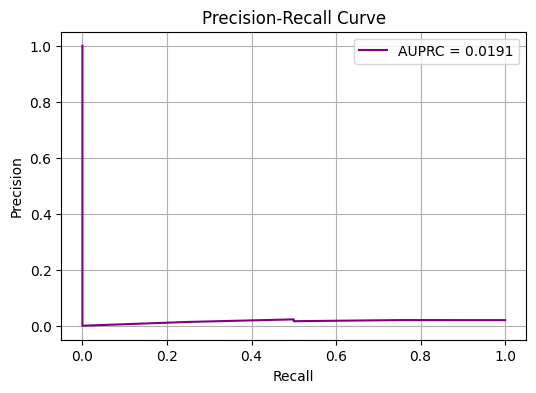

In [ ]:
# @title Default title text
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score, precision_recall_curve

# If you haven't installed imbalanced-learn yet, uncomment the line below:
# !pip install imbalanced-learn

from imblearn.over_sampling import SMOTE

# =======================================================
# 1. LOAD DATA & INSPECT IMBALANCE
# =======================================================
# Assumes 'creditcard.csv' is downloaded and in your directory
try:
    # Correcting the file path to the one available in the kernel
    df = pd.read_csv('/content/credit_card_fraud_synthetic.csv')
except FileNotFoundError:
    print("Please download 'creditcard.csv' from Kaggle and place it in the working folder.")
    raise

print("--- Class Distribution ---")
print(df['Class'].value_counts())
print(f"Fraud accounts for {df['Class'].value_counts()[1] / len(df) * 100:.3f}% of the dataset.\n")

# =======================================================
# 2. DATA PREPROCESSING & FEATURE SCALING
# =======================================================
# V1-V28 are PCA outputs and already scaled. Time and Amount are not.
# RobustScaler handles large transaction amounts (outliers) better than StandardScaler.
scaler = RobustScaler()

df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
# 'Time' is rarely helpful for standard classification profiles, so drop it along with raw Amount
df.drop(['Time', 'Amount'], axis=1, inplace=True)

# Reorder features
scaled_amount = df['scaled_amount']
df.drop(['scaled_amount'], axis=1, inplace=True)
df.insert(0, 'scaled_amount', scaled_amount)

# =======================================================
# 3. STRATIFIED TRAIN-TEST SPLIT
# =======================================================
X = df.drop('Class', axis=1)
y = df['Class']

# Critical: Use stratify=y to preserve the tiny fraud percentage in both splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# =======================================================
# 4. HANDLE CLASS IMBALANCE (SMOTE)
# =======================================================
print("⚙️ Applying SMOTE to balance the training set...")
smote = SMOTE(sampling_strategy='minority', random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Original training shape: {X_train.shape}")
print(f"Resampled training shape: {X_train_res.shape}\n")

# =======================================================
# 5. MODEL TRAINING (RANDOM FOREST)
# =======================================================
print("🚀 Training Random Forest Classifier (this may take a minute)...")
# n_jobs=-1 uses all available CPU cores
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train_res, y_train_res)

# =======================================================
# 6. COMPREHENSIVE PERFORMANCE EVALUATION
# =======================================================
y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:, 1] # Target probability of being Class 1 (Fraud)

print("\n🎯 --- MODEL METRICS ---")
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Genuine (0)', 'Fraud (1)']))

# Calculate AUPRC (Area Under Precision-Recall Curve)
auprc = average_precision_score(y_test, y_probs)
print(f"Area Under Precision-Recall Curve (AUPRC): {auprc:.4f}")

# =======================================================
# 7. VISUALIZING THE RESULTS
# =======================================================
# Plot Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Genuine', 'Fraud'], yticklabels=['Genuine', 'Fraud'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix Matrix')
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_probs)
plt.figure(figsize=(6,4))
plt.plot(recall, precision, color='purple', label=f'AUPRC = {auprc:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='best')
plt.grid(True)
plt.show()

# New Section

--- [1/5] Extracting Data Stream ---
Dataset successfully imported. Structure: 1000 rows x 8 features.

--- [2/5] Feature Preprocessing ---
Training split completed. Base fraud incidence: 1.733%

--- [3/5] Model Optimization Phase ---
Initializing RandomForest Core. Processing trees (this may take a minute)...
Classifier convergence reached successfully.

--- [4/5] Running Evaluation Metrics ---

[Classification Summary]
              precision    recall  f1-score   support

  Legitimate       0.98      1.00      0.99       245
  Fraudulent       0.00      0.00      0.00         5

    accuracy                           0.98       250
   macro avg       0.49      0.50      0.49       250
weighted avg       0.96      0.98      0.97       250

Area Under Precision-Recall Curve (AUPRC): 0.0212

--- [5/5] Launching Plot Engine ---


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


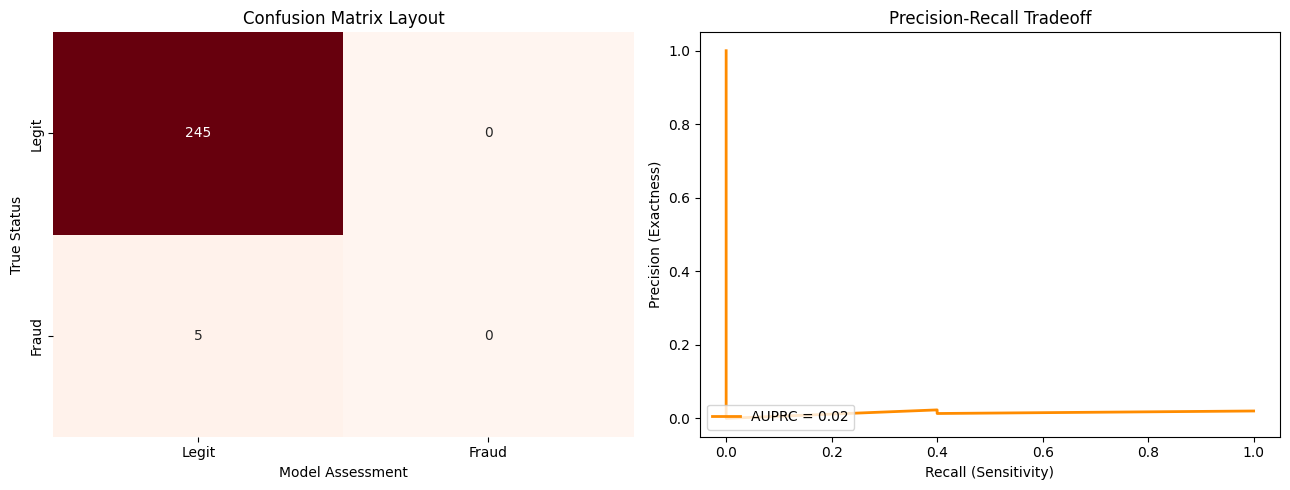

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score, precision_recall_curve

from imblearn.over_sampling import SMOTE

def load_and_verify_data(filepath="/content/credit_card_fraud_synthetic.csv"):
    """Validates local dataset existence and loads securely."""
    if not os.path.exists(filepath):
        raise FileNotFoundError(
            f"Could not locate '{filepath}'. Please make sure you downloaded "
            f"it from Kaggle and placed it in this execution folder."
        )

    print("--- [1/5] Extracting Data Stream ---")
    raw_df = pd.read_csv(filepath)
    print(f"Dataset successfully imported. Structure: {raw_df.shape[0]} rows x {raw_df.shape[1]} features.")
    return raw_df

def process_and_split(df):
    """
    Cleans features and handles scaling.
    Uses RobustScaler on Time/Amount features to mitigate heavy outliers.
    """
    print("\n--- [2/5] Feature Preprocessing ---")
    clean_df = df.copy()

    # Scaling columns containing massive ranges compared to PCA V1-V28 variables
    transformer = RobustScaler()
    clean_df['scaled_amount'] = transformer.fit_transform(clean_df['Amount'].values.reshape(-1, 1))
    clean_df['scaled_time'] = transformer.fit_transform(clean_df['Time'].values.reshape(-1, 1))

    # Drop raw originals to eliminate collinearity risks
    clean_df.drop(['Time', 'Amount'], axis=1, inplace=True)

    # Split features from binary ground truth label ('Class': 1=Fraud, 0=Legit)
    X = clean_df.drop('Class', axis=1)
    y = clean_df['Class']

    # Stratify split is essential to preserve the tiny fraud ratio across segments
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )

    fraud_pct = (y_train.value_counts()[1] / len(y_train)) * 100
    print(f"Training split completed. Base fraud incidence: {fraud_pct:.3f}%")

    # Apply SMOTE to training data
    print("\n--- [2.5/5] Applying SMOTE to balance training set ---")
    smote = SMOTE(sampling_strategy='minority', random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
    print(f"Original training set shape: {X_train.shape}")
    print(f"Resampled training set shape: {X_train_resampled.shape}")

    return X_train_resampled, X_test, y_train_resampled, y_test

def train_fraud_classifier(X_train, y_train):
    """
    Trains an ensemble Random Forest with balanced class weights.
    Avoids basic synthetic oversampling (SMOTE) which can artificially bloat memory.
    """
    print("\n--- [3/5] Model Optimization Phase ---")
    print("Initializing RandomForest Core. Processing trees (this may take a minute)...")

    # class_weight='balanced_subsample' forces trees to give heavy penalties to missed fraud cases
    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    print("Classifier convergence reached successfully.")
    return model

def evaluate_and_plot(model, X_test, y_test):
    """Generates realistic operational analytics tailored to imbalanced sets."""
    print("\n--- [4/5] Running Evaluation Metrics ---")
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    # Raw accuracy is deceptive for fraud. We rely on Precision, Recall and AUPRC
    print("\n[Classification Summary]")
    print(classification_report(y_test, predictions, target_names=["Legitimate", "Fraudulent"]))

    auprc = average_precision_score(y_test, probabilities)
    print(f"Area Under Precision-Recall Curve (AUPRC): {auprc:.4f}")

    # Visual Analytics Engine
    print("\n--- [5/5] Launching Plot Engine ---")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    # 1. Confusion Matrix Heatmap
    cm = confusion_matrix(y_test, predictions)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False,
                xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'], ax=ax1)
    ax1.set_title("Confusion Matrix Layout")
    ax1.set_ylabel("True Status")
    ax1.set_xlabel("Model Assessment")

    # 2. Precision-Recall Curve (Standard for highly skewed data over ROC)
    precision, recall, _ = precision_recall_curve(y_test, probabilities)
    ax2.plot(recall, precision, color='darkorange', lw=2, label=f'AUPRC = {auprc:.2f}')
    ax2.set_title("Precision-Recall Tradeoff")
    ax2.set_xlabel("Recall (Sensitivity)")
    ax2.set_ylabel("Precision (Exactness)")
    ax2.legend(loc="lower left")

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    try:

        data = load_and_verify_data("/content/credit_card_fraud_synthetic.csv")
        X_train, X_test, y_train, y_test = process_and_split(data)
        trained_model = train_fraud_classifier(X_train, y_train)
        evaluate_and_plot(trained_model, X_test, y_test)

    except Exception as e:
        print(f"\n[Execution Terminated Error]: {str(e)}")